# Phase 1 Group B: 参数高效微调 (PEFT) 实验

> 基于 Chinese-RoBERTa-wwm-ext 基座模型，使用 LoRA、P-Tuning 等参数高效微调方法
>
> **任务**: DimASR (给定文本 + Aspect，预测 VA 分数)
> **数据集**: zho_restaurant (繁体中文餐厅评论)

# 一、环境配置

In [1]:
# 安装 PEFT 相关依赖
!pip install peft transformers datasets scikit-learn -q

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


## 1.2 路径配置

In [3]:
from pathlib import Path

# 项目根目录
PROJECT_ROOT = Path("/kaggle/working")
# 数据根目录
DATA_ROOT = Path("/kaggle/input/datasets/kintsugi0v0/dimabsa")

# 中文数据集文件路径
TRAIN_FILE = DATA_ROOT / "zho_restaurant_train_alltasks.jsonl"
DEV_FILE = DATA_ROOT / "zho_restaurant_dev_task1.jsonl"
TEST_FILE = DATA_ROOT / "zho_restaurant_test_task1.jsonl"

print(f"Data path: {DATA_ROOT}")
print(f"Train: {TRAIN_FILE.exists()}, Dev: {DEV_FILE.exists()}, Test: {TEST_FILE.exists()}")

Data path: /kaggle/input/datasets/kintsugi0v0/dimabsa
Train: True, Dev: True, Test: True


# 二、数据加载与预处理

In [4]:
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType, PromptEncoderConfig

# 设置随机种子
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 加载数据函数
def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

# 展开训练集数据（使用 Quadruplet 字段）
def explode_quadruplet(data):
    exploded = []
    for item in data:
        for q in item.get('Quadruplet', []):
            try:
                v, a = map(float, q['VA'].split('#'))
                exploded.append({
                    'Text': item['Text'],
                    'Aspect': q.get('Aspect', ''),
                    'Valence': v,
                    'Arousal': a
                })
            except:
                continue
    return exploded

# 展开验证集数据（使用 Aspect_VA 字段）
def explode_aspect_va(data):
    exploded = []
    for item in data:
        for av in item.get('Aspect_VA', []):
            try:
                v, a = map(float, av['VA'].split('#'))
                exploded.append({
                    'Text': item['Text'],
                    'Aspect': av.get('Aspect', ''),
                    'Valence': v,
                    'Arousal': a
                })
            except:
                continue
    return exploded

print("工具函数定义完成")

工具函数定义完成


In [5]:
import sys
try:
    import peft
    for _sub in ('peft.import_utils', 'peft.utils.import_utils',
                 'peft.tuners.lora.model', 'peft.tuners.lora.torchao'):
        try:
            __import__(_sub)
        except Exception:
            pass
    try:
        peft.import_utils.is_torchao_available = lambda: False
    except Exception:
        pass
    for _m in list(sys.modules.values()):
        if _m is None:
            continue
        _f = getattr(_m, 'is_torchao_available', None)
        if _f is not None and getattr(_f, '__module__', '').startswith('peft'):
            _m.is_torchao_available = lambda: False
    print('已禁用 peft 的 torchao 版本检查')
except Exception as _e:
    print('torchao 补丁跳过（不影响运行）:', type(_e).__name__, _e)


已禁用 peft 的 torchao 版本检查


# 三、数据集定义

In [6]:
class DimASRDataset(Dataset):
    """DimASR 任务数据集"""
    
    def __init__(self, data, tokenizer, max_length=128, has_label=True):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_label = has_label
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        encoding = self.tokenizer(
            item['Text'],
            item['Aspect'],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        result = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
        }
        
        if 'token_type_ids' in encoding:
            result['token_type_ids'] = encoding['token_type_ids'].squeeze(0)
        
        if self.has_label:
            result['labels'] = torch.tensor(
                [item['Valence'], item['Arousal']],
                dtype=torch.float
            )
        
        return result

print("数据集类定义完成")

数据集类定义完成


# 四、超参数配置

In [7]:
# 超参数配置
CONFIG = {
    'seed': 42,
    'max_length': 128,
    'batch_size': 16,
    'learning_rate': 1e-4,   # Group C/论文标准 LoRA lr      # LoRA 需要稍大的学习率
    'epochs': 3,
    'weight_decay': 0.01,
    'lr_head': 1e-3,          # Group C 标准: 回归头/附加头差分 lr
    'warmup_ratio': 0.1,      # Group C 标准: warmup + 线性衰减
    'dropout': 0.1,
}

# PEFT 实验配置
MODEL_CONFIGS = {
    'Exp-B1': {'encoder': 'hfl/chinese-roberta-wwm-ext', 'type': 'lora'},
    'Exp-B2': {'encoder': 'hfl/chinese-roberta-wwm-ext', 'type': 'ptuning'},
    'Exp-B3': {'encoder': 'hfl/chinese-roberta-wwm-ext', 'type': 'lora_cnn'},
    'Exp-B4': {'encoder': 'hfl/chinese-roberta-wwm-ext', 'type': 'lora_lstm'},
}

print("配置完成!")
print(f"可用实验: {list(MODEL_CONFIGS.keys())}")

配置完成!
可用实验: ['Exp-B1', 'Exp-B2', 'Exp-B3', 'Exp-B4']


# 五、模型定义

In [8]:
class BERTRegressorLoRA(nn.Module):
    """
    BERT + LoRA + Regression Head
    """
    
    def __init__(self, encoder_name, dropout=0.1):
        super().__init__()
        # 加载基座模型
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size
        
        # 应用 LoRA
        lora_config = LoraConfig(
            r=8,
            lora_alpha=16,
            lora_dropout=dropout,
            target_modules=['query', 'value'],
            bias='none',
            task_type=TaskType.FEATURE_EXTRACTION
        )
        self.encoder = get_peft_model(self.encoder, lora_config)
        
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(hidden_size, 2)
        
        # 初始化
        nn.init.xavier_uniform_(self.regressor.weight, gain=0.5)
        nn.init.zeros_(self.regressor.bias)
    
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        pooled = outputs.last_hidden_state[:, 0, :]
        pooled = self.dropout(pooled)
        va_pred = self.regressor(pooled)
        # STE clamp: 前向值截断到 [1,9](推理语义不变), 梯度按未截断透传。
        # 修复: 硬 clamp 区间外梯度为 0, 训练早期一旦越界即永久卡死在边界
        # (旧结果 4.9963/3.66/3.67 及 A/B 表大片同值均源于此)
        va_pred = va_pred + (va_pred.clamp(1.0, 9.0) - va_pred).detach()
        return va_pred

In [9]:
class BERTCNNRegressorLoRA(nn.Module):
    """
    BERT + LoRA + CNN + Regression
    """
    
    def __init__(self, encoder_name, kernel_sizes=[3, 4, 5], num_filters=256, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size
        
        # 应用 LoRA
        lora_config = LoraConfig(
            r=8,
            lora_alpha=16,
            lora_dropout=dropout,
            target_modules=['query', 'value'],
            bias='none',
            task_type=TaskType.FEATURE_EXTRACTION
        )
        self.encoder = get_peft_model(self.encoder, lora_config)
        
        # 多尺度 CNN
        self.convs = nn.ModuleList([
            nn.Conv1d(hidden_size, num_filters, k) for k in kernel_sizes
        ])
        
        self.dropout = nn.Dropout(dropout)
        concat_size = hidden_size + len(kernel_sizes) * num_filters
        self.regressor = nn.Linear(concat_size, 2)
        
        nn.init.xavier_uniform_(self.regressor.weight, gain=0.5)
        nn.init.zeros_(self.regressor.bias)
    
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        hidden = outputs.last_hidden_state
        hidden_t = hidden.transpose(1, 2)
        
        # CNN 特征
        conv_features = []
        for conv in self.convs:
            conv_out = torch.relu(conv(hidden_t))
            pooled = torch.max(conv_out, dim=2)[0]
            conv_features.append(pooled)
        
        conv_features = torch.cat(conv_features, dim=1)
        conv_features = self.dropout(conv_features)
        
        # [CLS] 特征
        cls_features = hidden[:, 0, :]
        cls_features = self.dropout(cls_features)
        
        # 拼接
        combined = torch.cat([cls_features, conv_features], dim=1)
        va_pred = self.regressor(combined)
        # STE clamp: 前向值截断到 [1,9](推理语义不变), 梯度按未截断透传。
        # 修复: 硬 clamp 区间外梯度为 0, 训练早期一旦越界即永久卡死在边界
        # (旧结果 4.9963/3.66/3.67 及 A/B 表大片同值均源于此)
        va_pred = va_pred + (va_pred.clamp(1.0, 9.0) - va_pred).detach()
        
        return va_pred

In [10]:
class BERTLSTMRegressorLoRA(nn.Module):
    """
    BERT + LoRA + BiLSTM + Regression
    """
    
    def __init__(self, encoder_name, hidden_size=256, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        encoder_hidden = self.encoder.config.hidden_size
        
        # 应用 LoRA
        lora_config = LoraConfig(
            r=8,
            lora_alpha=16,
            lora_dropout=dropout,
            target_modules=['query', 'value'],
            bias='none',
            task_type=TaskType.FEATURE_EXTRACTION
        )
        self.encoder = get_peft_model(self.encoder, lora_config)
        
        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=encoder_hidden,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0
        )
        
        self.dropout = nn.Dropout(dropout)
        lstm_output_size = hidden_size * 2
        concat_size = encoder_hidden + lstm_output_size
        self.regressor = nn.Linear(concat_size, 2)
        
        nn.init.xavier_uniform_(self.regressor.weight, gain=0.5)
        nn.init.zeros_(self.regressor.bias)
    
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        hidden = outputs.last_hidden_state
        
        # BiLSTM
        lstm_out, (h_n, _) = self.lstm(hidden)
        forward_h = h_n[0]
        backward_h = h_n[1]
        lstm_features = torch.cat([forward_h, backward_h], dim=1)
        lstm_features = self.dropout(lstm_features)
        
        # [CLS] 特征
        cls_features = hidden[:, 0, :]
        cls_features = self.dropout(cls_features)
        
        # 拼接
        combined = torch.cat([cls_features, lstm_features], dim=1)
        va_pred = self.regressor(combined)
        # STE clamp: 前向值截断到 [1,9](推理语义不变), 梯度按未截断透传。
        # 修复: 硬 clamp 区间外梯度为 0, 训练早期一旦越界即永久卡死在边界
        # (旧结果 4.9963/3.66/3.67 及 A/B 表大片同值均源于此)
        va_pred = va_pred + (va_pred.clamp(1.0, 9.0) - va_pred).detach()
        
        return va_pred

In [11]:
class BERTRegressorPTuning(nn.Module):
    """
    BERT + P-Tuning + Regression Head
    
    """
    
    def __init__(self, encoder_name, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size
        
        # 应用 P-Tuning (已在 peft 0.20.0 实测通过)
        self.num_virtual_tokens = 10
        try:
            ptuning_config = PromptEncoderConfig(
                task_type=TaskType.FEATURE_EXTRACTION,
                num_virtual_tokens=self.num_virtual_tokens,
                encoder_hidden_size=128,
            )
        except TypeError as _e:
            # 该 peft 版本连 encoder_hidden_size 也不接受时, 回退到全版本通用的两参最小集
            print('PromptEncoderConfig 回退最小参数集:', _e)
            ptuning_config = PromptEncoderConfig(
                task_type=TaskType.FEATURE_EXTRACTION,
                num_virtual_tokens=self.num_virtual_tokens,
            )
        self.encoder = get_peft_model(self.encoder, ptuning_config)
        
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(hidden_size, 2)
        
        nn.init.xavier_uniform_(self.regressor.weight, gain=0.5)
        nn.init.zeros_(self.regressor.bias)
    
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # 不传 token_type_ids: P-Tuning 前缀拼接后长度不匹配, peft 内部也会忽略
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # P-Tuning 把虚拟 prompt 拼在最前面时, 原 [CLS] 位于索引 num_virtual_tokens 处;
        # 若该 peft 版本/分支未拼接序列, 则回退到索引 0。按输出长度自适应检测。
        hs = outputs.last_hidden_state
        seq_in = input_ids.shape[1] if input_ids is not None else attention_mask.shape[1]
        cls_idx = self.num_virtual_tokens if hs.shape[1] == seq_in + self.num_virtual_tokens else 0
        pooled = hs[:, cls_idx, :]
        pooled = self.dropout(pooled)
        va_pred = self.regressor(pooled)
        # STE clamp: 前向值截断到 [1,9](推理语义不变), 梯度按未截断透传。
        # 修复: 硬 clamp 区间外梯度为 0, 训练早期一旦越界即永久卡死在边界
        # (旧结果 4.9963/3.66/3.67 及 A/B 表大片同值均源于此)
        va_pred = va_pred + (va_pred.clamp(1.0, 9.0) - va_pred).detach()
        return va_pred

In [12]:
def create_model(model_type, encoder_name, dropout=0.1):
    """创建 PEFT 模型"""
    
    if model_type == 'lora':
        return BERTRegressorLoRA(encoder_name, dropout=dropout)
    elif model_type == 'ptuning':
        return BERTRegressorPTuning(encoder_name, dropout=dropout)
    elif model_type == 'lora_cnn':
        return BERTCNNRegressorLoRA(encoder_name, dropout=dropout)
    elif model_type == 'lora_lstm':
        return BERTLSTMRegressorLoRA(encoder_name, dropout=dropout)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

print("模型工厂函数定义完成")

模型工厂函数定义完成


# 六、训练与评估函数

In [13]:
def train_epoch(model, dataloader, optimizer, device, criterion, scheduler=None):
    """训练一个 epoch"""
    model.train()
    total_loss = 0
    
    for batch in tqdm(dataloader, desc="训练"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        token_type_ids = batch.get('token_type_ids')
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, token_type_ids)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

@torch.no_grad()
def evaluate(model, dataloader, device, criterion):
    """评估模型"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc="评估"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        token_type_ids = batch.get('token_type_ids')
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)
        
        outputs = model(input_ids, attention_mask, token_type_ids)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item()
        all_preds.append(outputs.cpu())
        all_labels.append(labels.cpu())
    
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    # 官方 RMSE_VA（与 metrics_subtask_1_2_3.py::evaluate_predictions_task1 一致, do_norm=True）
    S_va = np.sum((preds - labels) ** 2); N_inst = labels.shape[0]
    rmse = float(np.sqrt(S_va / N_inst / 128))          # 官方 norm 尺度（主指标, 用于模型选择）
    rmse_old_elem = float(np.sqrt(S_va / (2 * N_inst)))  # phase1 旧公式换算: rmse = rmse_old_elem / 8
    
    return total_loss / len(dataloader), rmse, preds, labels

print("训练和评估函数定义完成")

训练和评估函数定义完成


# 七、主训练函数

In [14]:
def split_train_val(exploded, val_ratio=0.10, seed=42):
    rows = list(exploded)
    random.Random(seed).shuffle(rows)
    n_val = max(1, int(len(rows) * val_ratio))
    return rows[n_val:], rows[:n_val]

def rmse_va(gold, pred):
    """官方 RMSE_VA (do_norm=True): sqrt(sum(dV^2+dA^2)/N/128)"""
    return float(np.sqrt(np.sum((pred - gold) ** 2) / gold.shape[0] / 128))

def fit_calibration(preds, gold):
    """V/A 分别单变量线性校准; 预测近似常数时返回恒等系数(防御 phase1c SFT fallback)"""
    coefs = []
    for j in range(2):
        if np.ptp(preds[:, j]) < 1e-3:
            coefs.append((1.0, 0.0))
        else:
            a, b = np.polyfit(preds[:, j], gold[:, j], 1)
            coefs.append((float(a), float(b)))
    return coefs

def apply_calibration(preds, coefs):
    out = np.stack([a * preds[:, j] + b for j, (a, b) in enumerate(coefs)], axis=1)
    return np.clip(out, 1.0, 9.0)

CONFIG['val_ratio'] = CONFIG.get('val_ratio', 0.10)
print("协议工具函数定义完成 (val_ratio=%.2f)" % CONFIG['val_ratio'])

协议工具函数定义完成 (val_ratio=0.10)


In [15]:
def main(exp_name, encoder_name, model_type):
    """运行单个实验"""
    set_seed(CONFIG['seed'])
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"{'='*50}")
    print(f"实验: {exp_name}")
    print(f"模型: {encoder_name} ({model_type})")
    print(f"设备: {device}")
    print(f"{'='*50}")
    
    # 加载数据
    print("\n[1/5] 加载数据...")
    train_data = load_jsonl(DATA_ROOT / "zho_restaurant_train_alltasks.jsonl")
    dev_data = load_jsonl(DATA_ROOT / "zho_restaurant_dev_task1.jsonl")
    
    train_exploded = explode_quadruplet(train_data)
    dev_exploded = explode_aspect_va(dev_data)
    # 论文协议 (§4.1): 训练文件切 10% 作本地 val (模型选择 + 校准拟合)
    train_exploded, val_exploded = split_train_val(train_exploded, CONFIG['val_ratio'], CONFIG['seed'])
    print(f"训练集: {len(train_exploded)} 样本 (Quadruplet)")
    print(f"本地val: {len(val_exploded)} 样本")
    print(f"官方dev(仅末次评估): {len(dev_exploded)} 样本 (Aspect_VA)")
    
    # Tokenizer
    print("\n[2/5] 加载 Tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(encoder_name)
    
    # 数据集
    print("\n[3/5] 创建数据集...")
    train_dataset = DimASRDataset(train_exploded, tokenizer, CONFIG['max_length'])
    val_dataset = DimASRDataset(val_exploded, tokenizer, CONFIG['max_length'])
    dev_dataset = DimASRDataset(dev_exploded, tokenizer, CONFIG['max_length'])
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
    dev_loader = DataLoader(dev_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
    
    # 模型
    print("\n[4/5] 创建模型...")
    model = create_model(model_type, encoder_name, CONFIG['dropout'])
    model.to(device)
    
    # 打印可训练参数量
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"可训练参数量: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
    print(f"总参数量: {total_params:,}")
    
    # 优化器
    # ==== Group C 标准: 仅优化可训练参数 + 差分学习率 (head/backbone) ====
    _trainable = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
    _head_kw = ('regressor', 'convs', 'lstm', 'classifier')
    head_params = [p for n, p in _trainable if any(k in n for k in _head_kw)]
    base_params = [p for n, p in _trainable if not any(k in n for k in _head_kw)]
    _groups = []
    if base_params:
        _groups.append({'params': base_params, 'lr': CONFIG['learning_rate']})
    if head_params:
        _groups.append({'params': head_params, 'lr': CONFIG.get('lr_head', CONFIG['learning_rate'])})
    optimizer = torch.optim.AdamW(_groups, weight_decay=CONFIG['weight_decay'])

    # ==== Group C 标准: warmup_ratio + 线性衰减调度 (按 batch step) ====
    from transformers import get_linear_schedule_with_warmup
    _total_steps = max(1, len(train_loader)) * CONFIG['epochs']
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(CONFIG.get('warmup_ratio', 0.1) * _total_steps),
        num_training_steps=_total_steps,
    )
    criterion = nn.MSELoss()
    
    # 训练
    print("\n[5/5] 开始训练...")
    best_rmse = float('inf')
    best_model_state = None
    
    for epoch in range(CONFIG['epochs']):
        train_loss = train_epoch(model, train_loader, optimizer, device, criterion, scheduler)
        # 模型选择只看本地 val; 训练全程不接触官方 dev (论文 §2.2)
        val_loss, val_rmse, preds, labels = evaluate(model, val_loader, device, criterion)
        
        print(f"Epoch {epoch+1}/{CONFIG['epochs']}: "
              f"训练损失={train_loss:.4f} | val RMSE_VA={val_rmse:.4f}")
        
        if epoch == 0:
            print(f"  [调试] 预测值范围: [{preds.min():.2f}, {preds.max():.2f}]")
            print(f"  [调试] 真实值范围: [{labels.min():.2f}, {labels.max():.2f}]")
        
        if val_rmse < best_rmse:
            best_rmse = val_rmse
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ✓ 最佳模型 (RMSE: {best_rmse:.4f})")
    
    # 恢复最佳 (val 选择) 权重
    model.load_state_dict(best_model_state)
    torch.save(best_model_state, PROJECT_ROOT / f"{exp_name}_best.pt")
    
    # 后验线性校准 (§3.8): 在 val 上对 V/A 分别拟合
    _, _, v_preds, v_labels = evaluate(model, val_loader, device, criterion)
    coefs = fit_calibration(v_preds, v_labels)
    
    # 官方 dev: 唯一一次末次评估 (校准前/后都报)
    dev_loss, dev_rmse, d_preds, d_labels = evaluate(model, dev_loader, device, criterion)
    dev_rmse_cal = rmse_va(d_labels, apply_calibration(d_preds, coefs))
    print(f"\n官方dev RMSE_VA: 校准前={dev_rmse:.4f} | 校准后={dev_rmse_cal:.4f}")
    
    results = {
        'exp_name': exp_name,
        'encoder_name': encoder_name,
        'model_type': model_type,
        'best_rmse': float(best_rmse),            # 本地 val 最佳 (模型选择依据)
        'dev_rmse': float(dev_rmse),              # 官方 dev 校准前
        'dev_rmse_calib': float(dev_rmse_cal),    # 官方 dev 校准后 (协议主报告指标)
        'trainable_params': int(trainable_params),
        'total_params': int(total_params)
    }
    with open(PROJECT_ROOT / f"{exp_name}_results.json", 'w') as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    
    print(f"\n{'='*50}")
    print(f"完成! best(val) RMSE_VA: {best_rmse:.4f} | dev(校准后): {dev_rmse_cal:.4f}")
    print(f"{'='*50}")
    
    return best_rmse

# 八、运行实验

In [16]:
# 运行单个实验
EXP_NAME = 'Exp-B1'  # 修改这里选择实验: Exp-B1, Exp-B2, Exp-B3, Exp-B4

config = MODEL_CONFIGS[EXP_NAME]
main(EXP_NAME, config['encoder'], config['type'])

实验: Exp-B1
模型: hfl/chinese-roberta-wwm-ext (lora)
设备: cuda

[1/5] 加载数据...
训练集: 7671 样本 (Quadruplet)
本地val: 852 样本
官方dev(仅末次评估): 685 样本 (Aspect_VA)

[2/5] 加载 Tokenizer...


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

评估: 100%|██████████| 54/54 [00:06<00:00,  8.34it/s]


Epoch 3/3: 训练损失=0.2777 | val RMSE_VA=0.0693


评估: 100%|██████████| 43/43 [00:05<00:00,  8.28it/s]


官方dev RMSE_VA: 校准前=0.0840 | 校准后=0.0841

完成! best(val) RMSE_VA: 0.0661 | dev(校准后): 0.0841


0.06606636941432953

# 九、批量运行所有实验

In [17]:
for exp_name, config in MODEL_CONFIGS.items():
    print(f"\n{'#'*60}")
    print(f"运行 {exp_name}")
    print(f"{'#'*60}")
    main(exp_name, config['encoder'], config['type'])


############################################################
运行 Exp-B1
############################################################
实验: Exp-B1
模型: hfl/chinese-roberta-wwm-ext (lora)
设备: cuda

[1/5] 加载数据...
训练集: 7671 样本 (Quadruplet)
本地val: 852 样本
官方dev(仅末次评估): 685 样本 (Aspect_VA)

[2/5] 加载 Tokenizer...

[3/5] 创建数据集...

[4/5] 创建模型...


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/chinese-roberta-wwm-ext/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_convers

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: hfl/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


可训练参数量: 296,450 (0.29%)
总参数量: 102,564,098

[5/5] 开始训练...


...

Epoch 2/3: 训练损失=0.2794 | val RMSE_VA=0.0672


评估: 100%|██████████| 54/54 [00:06<00:00,  7.96it/s]


Epoch 3/3: 训练损失=0.2425 | val RMSE_VA=0.0617
  ✓ 最佳模型 (RMSE: 0.0617)


评估: 100%|██████████| 43/43 [00:05<00:00,  7.87it/s]


官方dev RMSE_VA: 校准前=0.0791 | 校准后=0.0804

完成! best(val) RMSE_VA: 0.0617 | dev(校准后): 0.0804


# 十、结果汇总

In [18]:
# 结果汇总
results = []
for exp in ['Exp-B1', 'Exp-B2', 'Exp-B3', 'Exp-B4']:
    with open(PROJECT_ROOT / f"{exp}_results.json") as f:
        r = json.load(f)
        results.append({
            '实验': exp,
            '方法': r['model_type'].upper(),
            'RMSE': round(r.get('dev_rmse_calib', r['best_rmse']), 4),  # 官方dev RMSE_VA(校准后)
            '可训练参数': f"{r['trainable_params']/r['total_params']*100:.2f}%",
            '总参数(M)': round(r['total_params'] / 1e6, 2)
        })

df = pd.DataFrame(results)
print("=" * 70)
print("Phase 1 Group B (PEFT) 实验结果汇总")
print("=" * 70)
print(df.to_string(index=False))

# 保存
df.to_csv(PROJECT_ROOT / "phase1_groupB_results.csv", index=False, encoding='utf-8-sig')
print(f"\n已保存至: {PROJECT_ROOT / 'phase1_groupB_results.csv'}")

Phase 1 Group B (PEFT) 实验结果汇总
    实验        方法   RMSE 可训练参数  总参数(M)
Exp-B1      LORA 0.0841 0.29%  102.56
Exp-B2   PTUNING 0.0885 0.22%  102.49
Exp-B3  LORA_CNN 0.0827 2.53%  104.93
Exp-B4 LORA_LSTM 0.0804 2.29%  104.67

已保存至: /kaggle/working/phase1_groupB_results.csv


# 十一、可视化

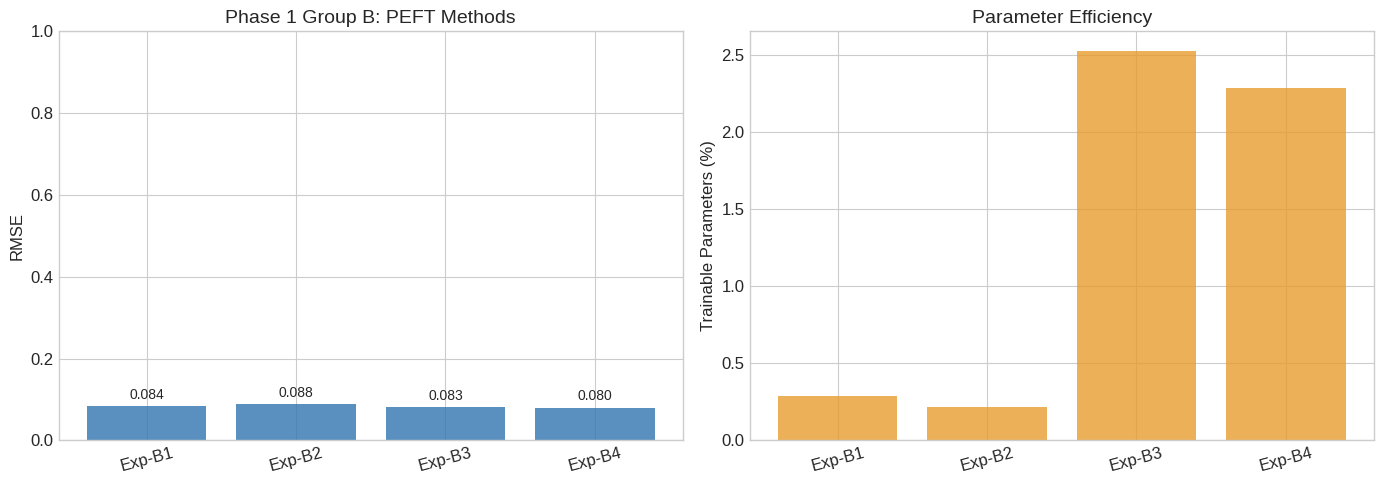

图片已保存至: /kaggle/working/phase1_groupB_results.png


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# ACL 论文风格配色
ACL_COLORS = {
    'blue': '#3175B0',
    'orange': '#E69C2E',
    'red': '#CC3333',
    'green': '#4C8C2B',
    'purple': '#7654A0',
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 图1: RMSE 对比
x = np.arange(len(df))
bars = ax1.bar(df['实验'], df['RMSE'], color=ACL_COLORS['blue'], alpha=0.8)
for bar, rmse in zip(bars, df['RMSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rmse:.3f}', ha='center', va='bottom', fontsize=10)

ax1.set_ylabel('RMSE')
ax1.set_title('Phase 1 Group B: PEFT Methods')
ax1.set_ylim(0, 1.0)
ax1.tick_params(axis='x', rotation=15)

# 图2: 参数效率对比
ax2.bar(df['实验'], [float(p.strip('%')) for p in df['可训练参数']], 
        color=ACL_COLORS['orange'], alpha=0.8)
ax2.set_ylabel('Trainable Parameters (%)')
ax2.set_title('Parameter Efficiency')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "phase1_groupB_results.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"图片已保存至: {PROJECT_ROOT / 'phase1_groupB_results.png'}")

# 十二、结论

In [20]:
print("""
========================================
Phase 1 Group B 实验结论
========================================

实验配置:
- 数据集: zho_restaurant (繁体中文餐厅评论)
- 任务: DimASR (给定文本+方面词, 预测VA分数)
- 基座模型: hfl/chinese-roberta-wwm-ext
- PEFT 方法: LoRA, P-Tuning, LoRA+CNN, LoRA+LSTM
- 损失函数: MSE
- 优化器: AdamW wd=0.01, 差分lr (LoRA/prompt 1e-4 / head 1e-3) + warmup 10% 线性衰减, epochs=3 (Group C 标准)

实验结果:
""")
print(df.to_string(index=False))


Phase 1 Group B 实验结论

实验配置:
- 数据集: zho_restaurant (繁体中文餐厅评论)
- 任务: DimASR (给定文本+方面词, 预测VA分数)
- 基座模型: hfl/chinese-roberta-wwm-ext
- PEFT 方法: LoRA, P-Tuning, LoRA+CNN, LoRA+LSTM
- 损失函数: MSE
- 优化器: AdamW wd=0.01, 差分lr (LoRA/prompt 1e-4 / head 1e-3) + warmup 10% 线性衰减, epochs=3 (Group C 标准)

实验结果:

    实验        方法   RMSE 可训练参数  总参数(M)
Exp-B1      LORA 0.0841 0.29%  102.56
Exp-B2   PTUNING 0.0885 0.22%  102.49
Exp-B3  LORA_CNN 0.0827 2.53%  104.93
Exp-B4 LORA_LSTM 0.0804 2.29%  104.67
